In [145]:
import numpy as np

In [ ]:
def hidden_layer(input_dim, output_dim):
    if output_dim != None:
        return np.random.rand(input_dim,output_dim)
    else:
        return np.random.rand(input_dim,)

class ModelNotReady(Exception):
        """Error raised when model isnt built"""
        pass
class InvalidInputSize(Exception):
    """Error raised when input size is incomplete"""
    pass
class model:

    def __init__(self,num_layers,input_size,output_size,hidden_layer_size=[]):
        self.num_layers = num_layers
        self.input_size = input_size
        self.model = []
        self.hidden_layer_size = hidden_layer_size
        self.output_size = output_size
        self.bias = []
        self.layers = []
        self.model = []


    def make(self):
        # hidden layer size tells the size of the neuron for each layer order wise
        if len(self.hidden_layer_size) != self.num_layers:
            print("error making the model")
            return None
        
        for i in range(self.num_layers):
            
            if i ==0:
                self.layers.append(hidden_layer(self.input_size,self.hidden_layer_size[i]))
                self.bias.append(hidden_layer(self.hidden_layer_size[i],None))
            if i+1 < self.num_layers:
                matrix_shape = (self.hidden_layer_size[i],self.hidden_layer_size[i+1])
                bias_shape = self.hidden_layer_size[i+1]
            else:
                matrix_shape = (self.hidden_layer_size[i],self.output_size)
                bias_shape = self.output_size
            
            self.layers.append(hidden_layer(*matrix_shape))
            if bias_shape != None:
                bias_layer = hidden_layer(bias_shape,None)
                self.bias.append(bias_layer)
            
        for layer,bias in zip(self.layers,self.bias):
            self.model.append((layer,bias))
        return self.model
    
    def forward_pass(self,input):
        if self.model == []:
            raise ModelNotReady("Please make the model first.")
        if not input.shape[1] == self.input_size:
            raise InvalidInputSize("the size of the input doesnt math the model's input architecture.")
        
        # forward propagation
        for layer in self.model:
            # Z = X.W+B
            input = np.dot(input,layer[0]) +layer[1]
        return input
            
        

        

# Creating a sample neural network below
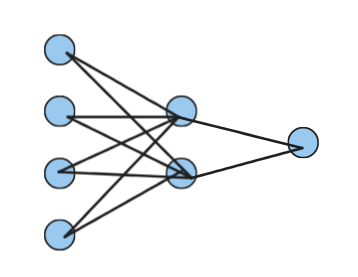

In [215]:
# input layer has 4 inputs and first hidden layer has 2 neurons and output is one
model_from_scratch = model(1,4,1,[2])
m=model_from_scratch.make()
input = np.random.rand(4,4)

In [217]:

model_from_scratch.forward_pass(input)

array([[2.79781301],
       [2.80676669],
       [2.60959832],
       [2.67787756]])

In [205]:
m[0][0][2][1]

np.float64(0.8177315564148808)

In [149]:
m_1 = model(2, 4, 1, [5, 3])

In [150]:
m_1.make()
m_1.forward_pass()

In [90]:
for layer in m:
    print("layer shape:",layer[0].shape," bias weight:",layer[1].shape)

layer shape: (4, 5)  bias weight: (5,)
layer shape: (5, 3)  bias weight: (3,)
layer shape: (3, 1)  bias weight: (1,)
